In [18]:
from matplotlib import pyplot as plt;
import requests;
from transformers import AutoTokenizer;
import numpy as np;


In [6]:
baseurl = 'https://www.gutenberg.org/cache/epub'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

tokenLenUniqueData = [];
tokenizer = AutoTokenizer.from_pretrained('gpt2');

In [ ]:
contentLenData = [[], [], [], []];
contentUniqueLentData = [[], [], [], []];
# tokenLenData = [];
# uniqueLenData = [];
for [code, title] in bookurls:
    url = f"{baseurl}/{code}/pg{code}.txt"
    bookContent = requests.get(url).text;
    gptTwoToken = tokenizer.encode(bookContent);
    bookWords = bookContent.split();
    
    contentLenData[0].append(title);
    contentUniqueLentData[0].append(title);
    
    contentLenData[1].append(len(bookContent));
    contentUniqueLentData[1].append(len(set(bookContent)));
    
    contentLenData[2].append(len(bookWords));
    contentUniqueLentData[2].append(len(set(bookWords)));
    
    contentLenData[3].append(len(gptTwoToken));
    contentUniqueLentData[3].append(len(set(gptTwoToken)));
    
    # tokenLenData.append([title, len(bookContent), len(bookWords), len(gptTwoToken)]);
    # uniqueLenData.append([title, len(set(bookContent)), len(set(bookWords)), len(set(gptTwoToken))]);

In [76]:
print("Total:");
print(f'  {"Book title":14} |  {"Chars":>7}  |  {"Words":>7}  |  {"Tokens":>7} ');
print('-----------------+-----------+-----------+-------------');
for i in range(len(bookurls)):
    print(f"{contentLenData[0][i]:16} |  {contentLenData[1][i]:>7,d}  |  {contentLenData[2][i]:>7d}  |  {contentLenData[3][i]:>7d}")
    
# for [title, bookContentlen, bookWordslen, gptTwoTokenlen] in tokenLenData:
#     print(f"{title:16} |  {bookContentlen:>7,d}  |  {bookWordslen:>7d}  |  {gptTwoTokenlen:>7d}");

print("\nUnique:");
print(f'  {"Book title":14} |  {"Chars":>7}  |  {"Words":>7}  |  {"Tokens":>7} ');
print('-----------------+-----------+-----------+-------------');
for i in range(len(bookurls)):
    print(f"{contentUniqueLentData[0][i]:16} |  {contentUniqueLentData[1][i]:>7,d}  |  {contentUniqueLentData[2][i]:>7d}  |  {contentUniqueLentData[3][i]:>7d}")

# for [title, bookContentlen, bookWordslen, gptTwoTokenlen] in uniqueLenData:
#     print(f"{title:16} |  {bookContentlen:>7,d}  |  {bookWordslen:>7d}  |  {gptTwoTokenlen:>7d}");


Total:
  Book title     |    Chars  |    Words  |   Tokens 
-----------------+-----------+-----------+-------------
Frankenstein     |  446,582  |    78106  |   114213
GreatGatsby      |  296,899  |    51262  |    89263
AliceWonderland  |  167,712  |    29569  |    52948
RomeoJuliet      |  167,469  |    29005  |    56180
HuckFinn         |  602,752  |   114130  |   193373
HeartDarkness    |  232,924  |    40957  |    63988
GrimmsTales      |  549,776  |   104156  |   158433
EdgarAllenPoe    |  632,171  |    98105  |   197302
WarOfTheWorlds   |  363,440  |    63118  |    96422
GulliversTravels |  611,781  |   108140  |   158340

Unique:
  Book title     |    Chars  |    Words  |   Tokens 
-----------------+-----------+-----------+-------------
Frankenstein     |       94  |    12179  |     9239
GreatGatsby      |       95  |    10210  |     8151
AliceWonderland  |       92  |     5973  |     4510
RomeoJuliet      |       92  |     6957  |     5196
HuckFinn         |       89  |    1430

In [ ]:
plotStyle = "hso";
_, ax = plt.subplots(1, 2, figsize=(10,3));

for i in range(1, 4):
    ax[0].plot(np.random.normal(i, 0.06, len(contentLenData[i])) , contentLenData[i], plotStyle[i - 1]);
    ax[0].plot([i-0.3, i+0.3], np.mean(contentLenData[i])*np.ones(2));
    
    ax[1].plot(np.random.normal(i, 0.06, len(contentUniqueLentData[i])) , contentUniqueLentData[i], plotStyle[i - 1]);
    ax[1].plot([i-0.3, i+0.3], np.mean(contentUniqueLentData[i])*np.ones(2));
    
ax[0].set(xticks=[1,2,3],xticklabels=['Characters','Words','Tokens'],ylabel='Count',title='A) Total');
ax[0].ticklabel_format(style='scientific',axis='y',scilimits=(0,0));
ax[1].set(xticks=[1,2,3],xticklabels=['Characters','Words','Tokens'],ylabel='Count',title='B) Unique');
ax[1].ticklabel_format(style='scientific',axis='y',scilimits=(0,0));

# characterPlotDataOne = [[],[],[]];
# for contentLendata in tokenLenData:
#     characterPlotDataOne[0].append(contentLendata[1]);
#     characterPlotDataOne[1].append(contentLendata[2]);
#     characterPlotDataOne[2].append(contentLendata[3]);

# characterPlotDataTwo = [[],[],[]];
# for uniquedata in uniqueLenData:
#     characterPlotDataTwo[0].append(uniquedata[1]);
#     characterPlotDataTwo[1].append(uniquedata[2]);
#     characterPlotDataTwo[2].append(uniquedata[3]);

# for i in range(3):
#     ax[0].plot(np.random.normal(i, 0.06, len(characterPlotDataOne[i])) , characterPlotDataOne[i], plotStyle[i]);
#     ax[0].plot([i-0.3, i+0.3], np.mean(characterPlotDataOne[i])*np.ones(2));
    
#     ax[1].plot(np.random.normal(i, 0.06, len(characterPlotDataTwo[i])) , characterPlotDataTwo[i], plotStyle[i]);
#     ax[1].plot([i-0.3, i+0.3], np.mean(characterPlotDataTwo[i])*np.ones(2));
# ax[0].plot(1, (contentLendata[2] for contentLendata in tokenLenData), "s", xticks="Words");
# ax[0].plot(2, (contentLendata[3] for contentLendata in tokenLenData), "o", xticks="GPT-2");

plt.tight_layout()
plt.show();

In [110]:
def findCoef(x: list, y: list) -> float:
    coef = np.corrcoef(x, y);
    positiveCoef = -1.0;
    # for i in coef:
    #     for j in i:
    #         j = round(j, 2);
    #         if((j < 1 and j > 0) and j > positiveCoef): 
    #             positiveCoef = j;
    # print(coef[0,1]);
    positiveCoef = coef[0,1];
    return positiveCoef;

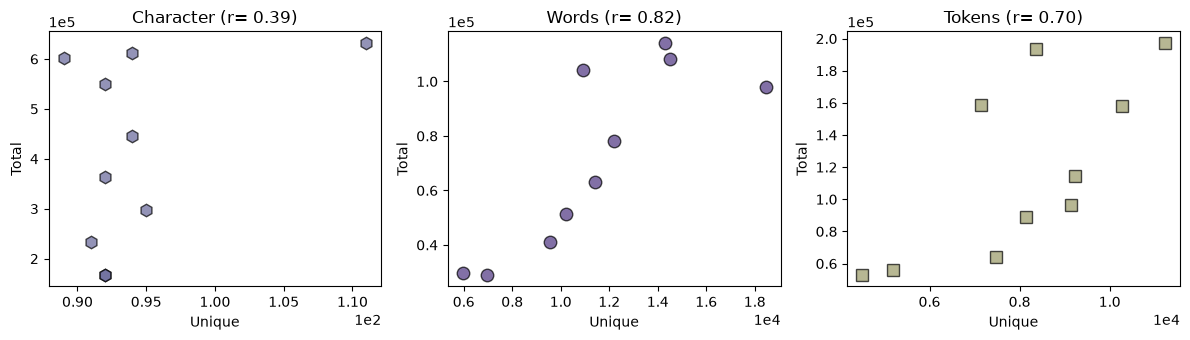

In [116]:
plotStyle = "hos";
colors = [[.4,.4,.6, .7], [.3,.2,.5,.7], [.6,.6,.4,.7]];
titles = ["Character", "Words", "Tokens"];

_, axs = plt.subplots(1, 3, figsize=(12,3.5));

for i in range(3):
    axs[i].plot(contentUniqueLentData[i + 1], contentLenData[i + 1], f"k{plotStyle[i]}", markerfacecolor=colors[i], markersize=9);
    axs[i].set(xlabel="Unique", ylabel="Total", title=f"{titles[i]} (r={findCoef(contentUniqueLentData[i + 1], contentLenData[i + 1]): .2f})");
    axs[i].ticklabel_format(style='scientific',axis='both',scilimits=(0,0));

plt.tight_layout();
plt.savefig("generated.png")
plt.show();
